# Model A
## NirK-only vs NirK+PCuAC

**Question**: Can NirK sequence-derived features predict whether a NirK-containing bacterial species also contains PCuAC?

**Notebook structure**
Data inspection -> Statistical exploration -> Feature relationships -> Model building -> Model interpretation 

**Goal**: Understand which sequence-derived NirK features differ between `nirK_only` and `both` species. Then, understand whether that differnce is strong and consistent enough to be predicitve.

### Dataset design
- Unite of analysis: one bacterial species = one row
- Target: 
    Using binary classification
    `0` = `nirK_only` species has NirK but not PCuAC
    `1` = `both` species has NirK and PCuAC
- Features:
    NirK sequence-derived physicochemical features only
    Length
    Molecular weight (MW)
    Isoelectric point (PI)
    GRAVY
    Aromaticity
    20 amino-acid composition fractions
- Notes
    `species`,`taxid`, `organism_name`, and accessions are taxonomy information only retained for reporting and not used in model inputs

### Notebook parameters and where

| Configuration | Section |
|---|---|
| `RANDOM_STATE`, `TEST_SIZE`, `CORR_THRESHOLD`, `CV_FOLDS`, `INPUT_PATH` | Section X.x |
| Logistic Regression `class_weight`, `max_depth`, `min_samples_leaf`, 


In [2]:
%pip install statsmodels

Note: you may need to restart the kernel to use updated packages.


## Data Loading & Inspection

In [3]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import mannwhitneyu
from statsmodels.stats.multitest import multipletests

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, RepeatedStratifiedKFold, cross_validate
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin, clone
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree, export_text, export_graphviz
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score, classification_report,
    RocCurveDisplay, PrecisionRecallDisplay, ConfusionMatrixDisplay,
)
from IPython.display import Image, display
import joblib

# Background for plots
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 100

print("Imports completed successfully.")

Imports completed successfully.


In [4]:
# File paths
INPUT_PATH = "final_feature_table.csv" # Save final feature table to the same destination as this notebook
OUTPUT_DIR = "results" # Figures, Tables, Models will be saved under these folders

# Parameters
RANDOM_STATE = 11 # Seed set for reproducibility of results in report
TEST_SIZE = 0.20 # Held-out test set proportion > Train/Test split of 80/20
CORR_THRESHOLD = 0.90 # If |r| > this threshold = one feature dropped
CV_FOLDS = 5 # Stratified CV folds used for tuning
ALPHA = 0.05 # Signifiance threshold for statistical testing 

# Feature names
AA_LETTERS = "ACDEFGHIKLMNPQRSTVWY"
BASE_NIRK_FEATURES = [
    "nirK_length", "nirK_molecular_weight", "nirK_isoelectric_point", 
    "nirK_gravy", "nirK_aromaticity",
]
AA_NIRK_FEATURES = [f"nirK_aa_frac_{aa}" for aa in AA_LETTERS]
ALL_NIRK_FEATURES = BASE_NIRK_FEATURES + AA_NIRK_FEATURES

METADATA_COLUMNS =[
    "species", "taxid", "organism_name", "nirK_rep_accession",
    "pcuac_rep_accession", "species_resolved", "nirK_present","pcuac_presnt",
]

# Output folders
for output in ("figures", "tables", "models"):
    os.makedirs(os.path.join(OUTPUT_DIR, output), exist_ok=True)

# Confirmation of features count
print(f"NirK features available: {len(ALL_NIRK_FEATURES)}")



NirK features available: 25


### Helper Functions

In [5]:
#testing docstrings
def test():
    """
    Testing to see which format i like better lol
    """
    pass

print(test.__doc__)


Testing to see which format i like better lol



In [6]:
def evaluate_model(model, X_test, y_test, model_name):
    """
    Returns evaluations of standard classiication metrics for a fitted model.
    """
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    baseline = max(y_test.mean(), 1 - y_test.mean())
    return {
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_pred),
        "naive_baseline_accuracy": baseline,
        "precision": precision_score(y_test, y_pred),
        "recall": recall_score(y_test, y_pred),
        "f1": f1_score(y_test, y_pred),
        "f1_macro": f1_score(y_test, y_pred, average="macro"),
        "roc_auc": roc_auc_score(y_test, y_proba),
        "pr_auc": average_precision_score(y_test, y_proba),
    }

In [7]:
def plot_model_evaluation(models_and_data: dict, y_test, suptitle=None, savepath_prefix=None):
    """
    Plot ROC and precision-recall (PR) curves for 1 >= fitted models
    evaluated on held-out test data.

    For a single model, also generate a confusion matrix.
    For multiple models, only the ROC and PR curves are plotted.
    """
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for name, (model, X_te) in models_and_data.items():
        RocCurveDisplay.from_estimator(model, X_te, y_test, name=name, ax=axes[0])
        PrecisionRecallDisplay.from_estimator(model, X_te, y_test, name=name, ax=axes[1])
    axes[0].plot([0, 1], [0, 1], linestyle="--", color="gray", linewidth=1)
    axes[0].set_title("ROC curve" + (f"{suptitle}" if suptitle else ""))
    axes[1].set_title("Precision-Recall curve" + (f"{suptitle}" if suptitle else ""))
    fig.tight_layout()
    if savepath_prefix:
        fig.savefig(f"{savepath_prefix}_roc_pr.png", dpi=200, bbox_inches="tight")
    plt.show()

    if len(models_and_data) == 1:
        name, (model, X_te) = next(iter(models_and_data.items()))
        fig2, ax2 = plt.subplots(figsize=(4.5, 4))
        ConfusionMatrixDisplay.from_estimator(
            model, X_te, y_test, display_labels=["nirK_only", "both"],
            cmap="PuBu", colorbar=False, ax=ax2,
        )
        ax2.set_title(f"Confusion matrix for {name} model")
        fig2.tight_layout()
        if savepath_prefix:
            fig2.savefig(f"{savepath_prefix}_confusion.png", dpi=200, bbox_inches="tight")
        plt.show()

In [8]:
def get_permutation_importance(model, X_test, y_test, feature_names, n_repeats=30):
    result = permutation_importance(
        model, X_test, y_test, scoring="f1",
        n_repeats=n_repeats, random_state=RANDOM_STATE, n_jobs=-1,
    )
    return pd.DataFrame({
        "feature": feature_names,
        "mean_importance": result.importances_mean,
        "std_importance": result.importances_std,
    }).sort_values("mean_importance", ascending=False).reset_index(drop=True)

In [9]:
def plot_importance_bar(importance_df, value_col, title, savepath=None, top_n=15, color="#7F793B"):
    top = importance_df.head(top_n).iloc[::-1]
    fig, ax = plt.subplots(figsize=(7, max(4, 0.3 * len(top))))
    xerr = top["std_importance"] if "std_importance" in top.columns else None
    ax.barh(top["feature"], top[value_col], xerr=xerr, color=color)
    ax.set_xlabel(value_col)
    ax.set_title(title)
    fig.tight_layout()
    if savepath:
        fig.savefig(savepath, dpi=200, bbox_inches="tight")
    plt.show()

### Load dataset

In [11]:
df_raw = pd.read_csv(INPUT_PATH)

print("Shape:", df_raw.shape)
display(df_raw.head())
print(f"The full final dataset contains {df_raw.shape[0]} species. \nThis the total number of species rows consisting of, \npcuac_only (n=3637) + nirK only (n=1717) + both (461).")

Shape: (5815, 59)


,species,taxid,organism_name,nirK_present,pcuac_present,class,nirK_rep_accession,pcuac_rep_accession,species_resolved,nirK_length,...,pcuac_aa_frac_M,pcuac_aa_frac_N,pcuac_aa_frac_P,pcuac_aa_frac_Q,pcuac_aa_frac_R,pcuac_aa_frac_S,pcuac_aa_frac_T,pcuac_aa_frac_V,pcuac_aa_frac_W,pcuac_aa_frac_Y
0,neisseria meningitidis,1053687;1069614;1069618;1095666;1095672;109569...,Neisseria meningitidis,1,1,both,WP_002258661.1,WP_002212839.1,1,392.0,...,0.07006,0.02548,0.03185,0.03185,0.02548,0.03822,0.03822,0.10191,0.00637,0.00637
1,cutibacterium acnes,1031709;1182749;1292038;1302634;1302635;130263...,Cutibacterium acnes,1,0,nirK_only,WP_002512805.1,NaN,1,314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,cutibacterium modestum,1182753;1182754;1912223;2559073;765109;765123;...,Cutibacterium modestum 31N;Cutibacterium modestum,1,0,nirK_only,WP_002529289.1,NaN,1,314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,[propionibacterium] namnetense,1051006;1574624,[Propionibacterium] namnetense SK182B-JCVI;Cut...,1,0,nirK_only,WP_002550210.1,NaN,1,314.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,simonsiella muelleri,641147;72;72,Simonsiella muelleri,1,1,both,WP_002642011.1,WP_002641845.1,1,387.0,...,0.03030,0.06061,0.04545,0.03030,0.02273,0.04545,0.10606,0.12121,0.00000,0.01515


The full final dataset contains 5815 species. 
This the total number of species rows consisting of, 
pcuac_only (n=3637) + nirK only (n=1717) + both (461).


### Inspect dataset

In [12]:
n_species = len(df_raw)
n_features = len(ALL_NIRK_FEATURES)

print(f"Number of species (rows): {n_species}")
print(f"Number of NirK feature columns: {n_features}")
print(f"Total columns in file: {df_raw.shape[1]}")
print("\n")
print("Data types:")
print(df_raw.dtypes.value_counts())

Number of species (rows): 5815
Number of NirK feature columns: 25
Total columns in file: 59


Data types:
float64    50
object      6
int64       3
Name: count, dtype: int64


### Missing Values & Duplicates

In [13]:
eda_df = df_raw[df_raw["class"].isin(["nirK_only", "both"])].copy()

missing_summary = eda_df[ALL_NIRK_FEATURES].isna().sum()
missing_summary = missing_summary[missing_summary > 0]
if len(missing_summary):
    display(missing_summary)
else:
    print("No missing values in nirK features (nirK_only/both rows).")

n_duplicate_rows = eda_df.duplicated(subset=ALL_NIRK_FEATURES).sum()
print(f"\nFully duplicated NirK feature rows: {n_duplicate_rows}")

# Check by species ID separatley from features duplication (see Chapter 4 discussion: homology)
if "species" in eda_df.columns:
    n_duplicate_species = eda_df["species"].duplicated().sum()
    print(f"Duplicate species identifiers: {n_duplicate_species}")

No missing values in nirK features (nirK_only/both rows).

Fully duplicated NirK feature rows: 22
Duplicate species identifiers: 0


### Class balance

class
pcuac_only    3637
nirK_only     1717
both           461
Name: count, dtype: int64

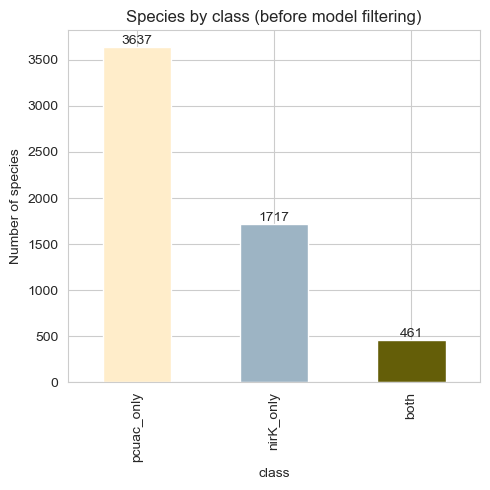

Model A subset (nirK_only + both):
class
nirK_only    1717
both          461
Name: count, dtype: int64
Class imbalance ratio: 3.72 :1


In [ ]:
class_counts = df_raw["class"].value_counts()
display(class_counts)

fig, ax = plt.subplots(figsize=(5,5))
class_counts.plot(kind="bar", ax = ax, color=["#FFEDCA", "#9DB4C4", "#645E08"])
ax.set_ylabel("Number of species")
ax.set_title("Species by class (before model filtering)")
for i, v in enumerate(class_counts.values):
    ax.text(i, v + max(class_counts.values) * 0.01, str(v), ha="center")
fig.tight_layout()
plt.show()

model_a_counts = eda_df["class"].value_counts()

print("Model A subset (nirK_only + both):")
print(model_a_counts)
print(f"Class imbalance ratio: {model_a_counts.max()/model_a_counts.min():.2f} :1")

### Feature distributions
`pcuac_only` species are not part of Model A and are excluded from here onward.

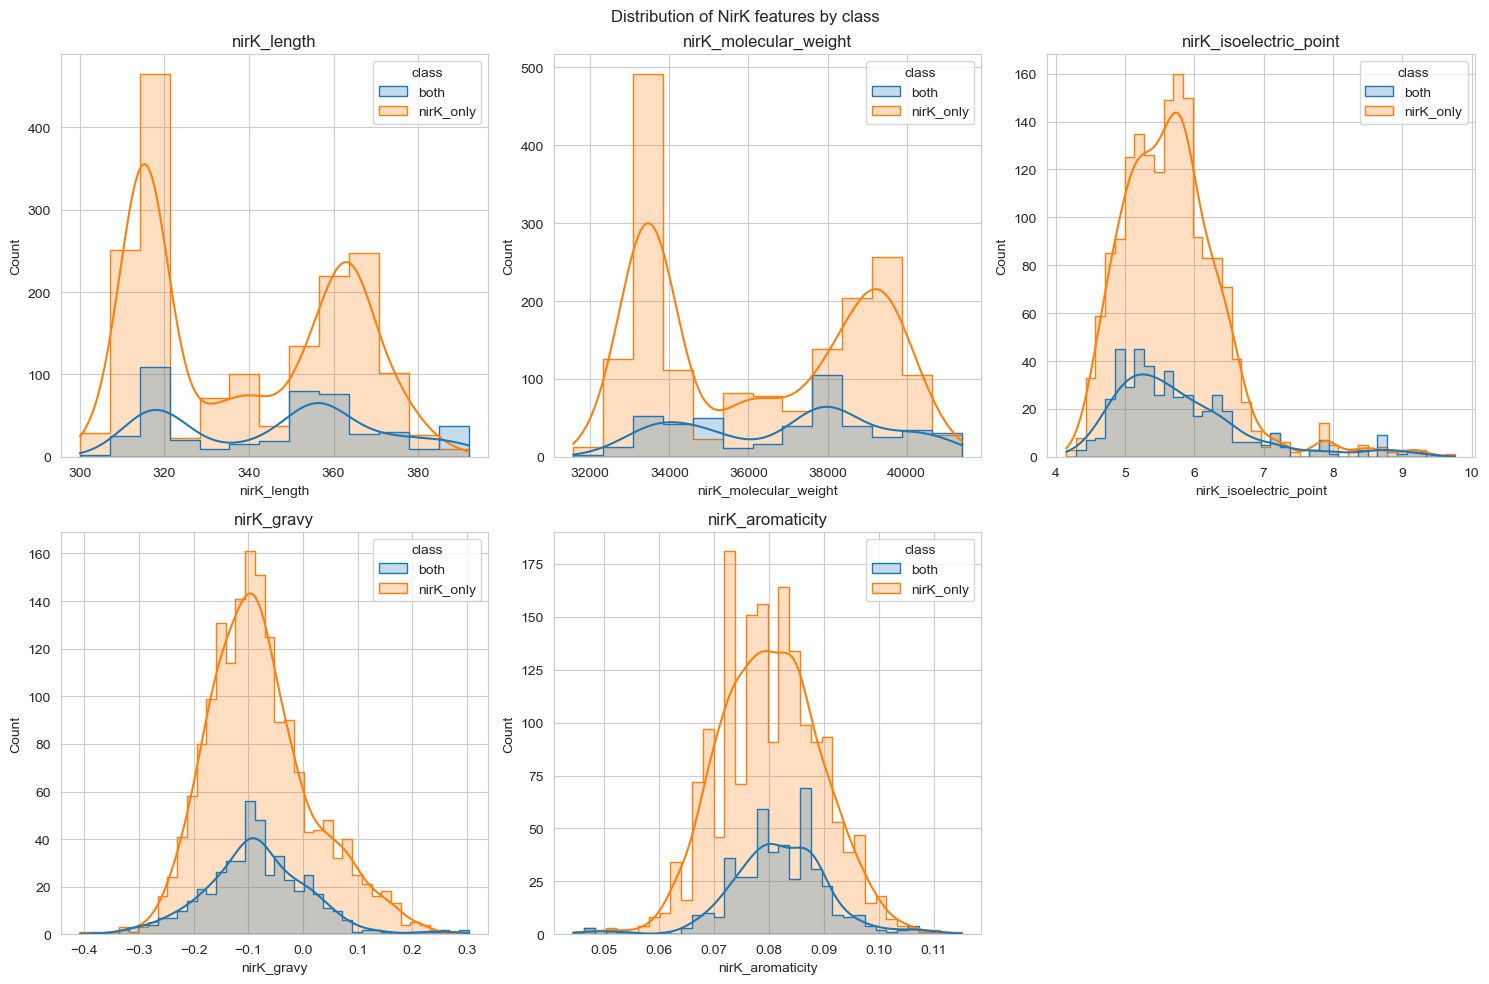

In [20]:
# Distribution of Model A NirK specific features by class
fig, axes = plt.subplots(2,3, figsize=(15,10))
for ax, feat in zip(axes.flat, BASE_NIRK_FEATURES):
    sns.histplot(data=eda_df, x=feat, hue="class", kde=True, element="step", ax=ax)
    ax.set_title(feat)
axes.flat[-1].axis("off")
fig.suptitle("Distribution of NirK features by class")
fig.tight_layout()
plt.show()

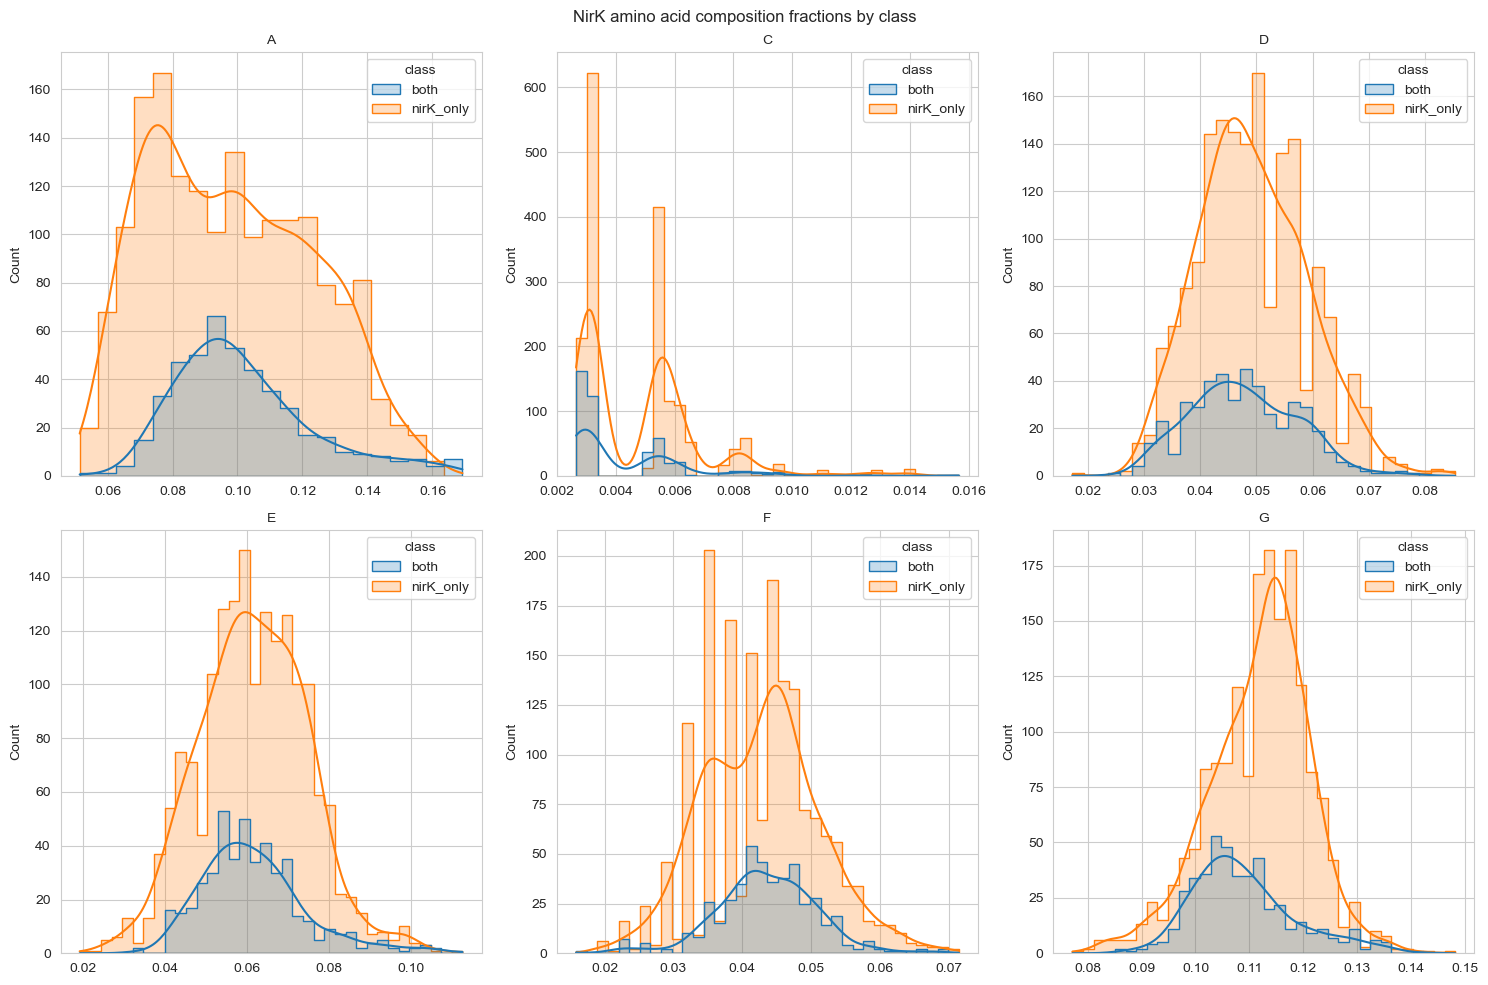

In [22]:
# Distribution of NirK amino acid composition fractions by class
fig, axes = plt.subplots(2,3, figsize=(15,10))
for ax, feat in zip(axes.flat, AA_NIRK_FEATURES):
    sns.histplot(data=eda_df, x=feat, hue="class", kde=True, element="step", ax=ax)
    ax.set_title(feat.replace("nirK_aa_frac_",""), fontsize=10)
    ax.set_xlabel("")
fig.suptitle("NirK amino acid composition fractions by class")
fig.tight_layout()
plt.show()

### Boxplots

/var/folders/g5/fxyr42v91dv_5cyx6gbg2t1w0000gn/T/ipykernel_20727/3849616449.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="class", y=feat, ax=ax, order=["nirK_only", "both"],
/var/folders/g5/fxyr42v91dv_5cyx6gbg2t1w0000gn/T/ipykernel_20727/3849616449.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="class", y=feat, ax=ax, order=["nirK_only", "both"],
/var/folders/g5/fxyr42v91dv_5cyx6gbg2t1w0000gn/T/ipykernel_20727/3849616449.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=eda_df, x="class", y=f

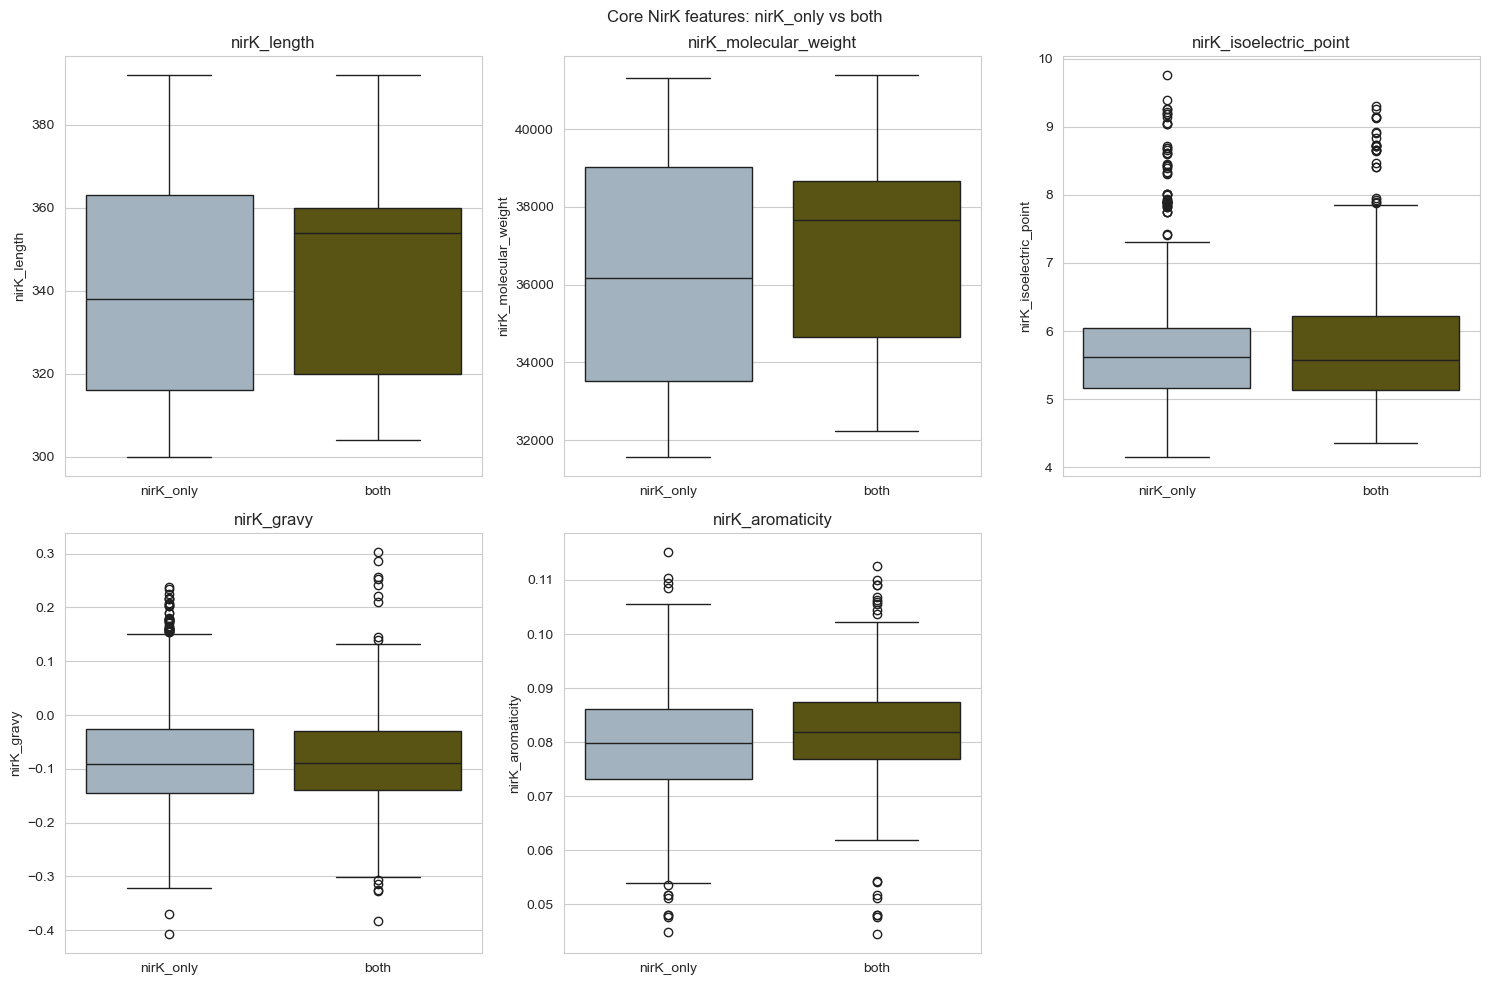

In [27]:
# Boxplots comparing nirK_only vs both
fig, axes = plt.subplots(2,3, figsize=(15,10))
for ax, feat in zip(axes.flat, BASE_NIRK_FEATURES):
    sns.boxplot(data=eda_df, x="class", y=feat, ax=ax, order=["nirK_only", "both"], 
                palette={"nirK_only": "#9DB4C4", "both": "#645E08" },
                legend=False)
    ax.set_title(feat)
    ax.set_xlabel("")
axes.flat[-1].axis("off")
fig.suptitle("Core NirK features: nirK_only vs both")
fig.tight_layout()
plt.show()

# Save to outputs folder
fig.savefig(os.path.join(OUTPUT_DIR, "figures", "eda_boxplots_model_A.png"), dpi=200, bbox_inches="tight")

## Statistical Analysis


Feature by feature question on whether the feature actually differs between nirK_only and both species?

The statistical testing offers insight as to whether a feature differs between groups but does not answer whether the feature can predict class membership.

### Mann-Whitney U tests with effect size